# <center><strong>Airbnb Price Analysis</strong></center>
-------------------

#### **By Mohamed Jamyl**

http://linkedin.com/in/mohamed-jamyl

https://www.kaggle.com/mohamedjamyl

https://github.com/Mohamed-Jamyl

--------------------------------
--------------------------------
## **Import Libraries**
--------------------------------

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

------------------------------------------
## **Initial functions**
------------------------------------------

In [2]:
def countplot(data,col):
    sns.countplot(x=col, data=data)
    plt.xlabel('Year')
    plt.show()

def pie(data,col):
    data[col].value_counts().plot.pie(autopct='%0.2f%%')
    plt.show()

def boxplot(data, col):
    fig, axes = plt.subplots(nrows=1,ncols=1)
    fig.set_size_inches(8, 4)
    sns.boxplot(data=data,x=col,orient="o",ax=axes)
    plt.show()

def boxplot2(data, x,y):
    fig, axes = plt.subplots(nrows=1,ncols=1)
    fig.set_size_inches(10, 5)
    sns.boxplot(data=data,y=y,x=x,orient="v",ax=axes)
    plt.show()

def kde (data,col):
    plt.figure(figsize=(8,	4))
    sns.kdeplot(data[col], fill=True,	color='violet', alpha=0.6)
    plt.title(f'Kernel Density Estimate(KDE) - {col}',	fontsize=16)
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Density', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

def countplot(data,col):
    sns.countplot(x=col, data=data)
    plt.xlabel('Year')
    plt.show()

def pie(data,col):
    data[col].value_counts().plot.pie(autopct='%0.2f%%')
    plt.title(col)
    plt.show()

def boxplot(data, col):
    fig, axes = plt.subplots(nrows=1,ncols=1)
    fig.set_size_inches(8, 4)
    sns.boxplot(data=data,x=col,orient="o",ax=axes)
    plt.show()

def boxplot2(data, x,y):
    fig, axes = plt.subplots(nrows=1,ncols=1)
    fig.set_size_inches(14, 5)
    sns.boxplot(data=data,y=y,x=x,orient="v",ax=axes)
    plt.show()

def kde (data,col):
    plt.figure(figsize=(8,	4))
    sns.kdeplot(data[col], fill=True,	color='violet', alpha=0.6)
    plt.title(f'Kernel Density Estimate(KDE) - {col}',	fontsize=16)
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Density', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

def group_distribution(data,col,target):

    groups = data[col].unique()
    
    plt.figure(figsize=(12, 6))
    
    for i, group in enumerate(groups):
        data_group = data[data[col] == group][target]
        
        plt.subplot(2, 2, i+1)
        sns.histplot(data_group, kde=True, color='green')
        plt.title(f'Distribution for {group}')
    
    plt.tight_layout()
    plt.show()

---------------------------------------
## **Data Exploring**
---------------------------------------

In [3]:
df = pd.read_csv('/kaggle/input/datasets/mohamedjamyl/airbnb/Listings.csv',encoding='latin1')

/tmp/ipykernel_58/3892426926.py:1: DtypeWarning: Columns (5,13) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/kaggle/input/datasets/mohamedjamyl/airbnb/Listings.csv',encoding='latin1')


In [4]:
df.head()

,listing_id,name,host_id,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_total_listings_count,...,minimum_nights,maximum_nights,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable
0,281420,"Beautiful Flat in le Village Montmartre, Paris",1466919,12/3/2011,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
1,3705183,39 mÃÂ² Paris (Sacre CÃ âur),10328771,11/29/2013,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
2,4082273,"Lovely apartment with Terrace, 60m2",19252768,7/31/2014,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
3,4797344,Cosy studio (close to Eiffel tower),10668311,12/17/2013,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
4,4823489,Close to Eiffel Tower - Beautiful flat : 2 rooms,24837558,12/14/2014,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f


In [5]:
df.shape

(279712, 33)

In [6]:
df.columns

Index(['listing_id', 'name', 'host_id', 'host_since', 'host_location',
       'host_response_time', 'host_response_rate', 'host_acceptance_rate',
       'host_is_superhost', 'host_total_listings_count',
       'host_has_profile_pic', 'host_identity_verified', 'neighbourhood',
       'district', 'city', 'latitude', 'longitude', 'property_type',
       'room_type', 'accommodates', 'bedrooms', 'amenities', 'price',
       'minimum_nights', 'maximum_nights', 'review_scores_rating',
       'review_scores_accuracy', 'review_scores_cleanliness',
       'review_scores_checkin', 'review_scores_communication',
       'review_scores_location', 'review_scores_value', 'instant_bookable'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 279712 entries, 0 to 279711
Data columns (total 33 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   listing_id                   279712 non-null  int64  
 1   name                         279537 non-null  object 
 2   host_id                      279712 non-null  int64  
 3   host_since                   279547 non-null  object 
 4   host_location                278872 non-null  object 
 5   host_response_time           150930 non-null  object 
 6   host_response_rate           150930 non-null  float64
 7   host_acceptance_rate         166625 non-null  float64
 8   host_is_superhost            279547 non-null  object 
 9   host_total_listings_count    279547 non-null  float64
 10  host_has_profile_pic         279547 non-null  object 
 11  host_identity_verified       279547 non-null  object 
 12  neighbourhood                279712 non-null  object 
 13 

In [8]:
df.isnull().sum()

listing_id                          0
name                              175
host_id                             0
host_since                        165
host_location                     840
host_response_time             128782
host_response_rate             128782
host_acceptance_rate           113087
host_is_superhost                 165
host_total_listings_count         165
host_has_profile_pic              165
host_identity_verified            165
neighbourhood                       0
district                       242700
city                                0
latitude                            0
longitude                           0
property_type                       0
room_type                           0
accommodates                        0
bedrooms                        29435
amenities                           0
price                               0
minimum_nights                      0
maximum_nights                      0
review_scores_rating            91405
review_score

In [9]:
df.columns

Index(['listing_id', 'name', 'host_id', 'host_since', 'host_location',
       'host_response_time', 'host_response_rate', 'host_acceptance_rate',
       'host_is_superhost', 'host_total_listings_count',
       'host_has_profile_pic', 'host_identity_verified', 'neighbourhood',
       'district', 'city', 'latitude', 'longitude', 'property_type',
       'room_type', 'accommodates', 'bedrooms', 'amenities', 'price',
       'minimum_nights', 'maximum_nights', 'review_scores_rating',
       'review_scores_accuracy', 'review_scores_cleanliness',
       'review_scores_checkin', 'review_scores_communication',
       'review_scores_location', 'review_scores_value', 'instant_bookable'],
      dtype='object')

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.drop_duplicates(inplace=True)

In [12]:
df['price'].describe().T

count    279712.000000
mean        608.792737
std        3441.826611
min           0.000000
25%          75.000000
50%         150.000000
75%         474.000000
max      625216.000000
Name: price, dtype: float64

In [13]:
df.select_dtypes(include='object').describe()

,name,host_since,host_location,host_response_time,host_is_superhost,host_has_profile_pic,host_identity_verified,neighbourhood,district,city,property_type,room_type,amenities,instant_bookable
count,279537,279547,278872,150930,279547,279547,279547,279712,37012,279712,279712,279712,279712,279712
unique,265860,4240,7159,4,2,2,2,660,5,10,144,4,245003,2
top,home away from home,9/2/2019,"Paris, Ile-de-France, France",within an hour,f,t,t,I Centro Storico,Manhattan,Paris,Entire apartment,Entire place,"[""Long term stays allowed""]",f
freq,98,710,47794,83464,229294,278631,201191,14874,16553,64690,138989,182005,1388,164105


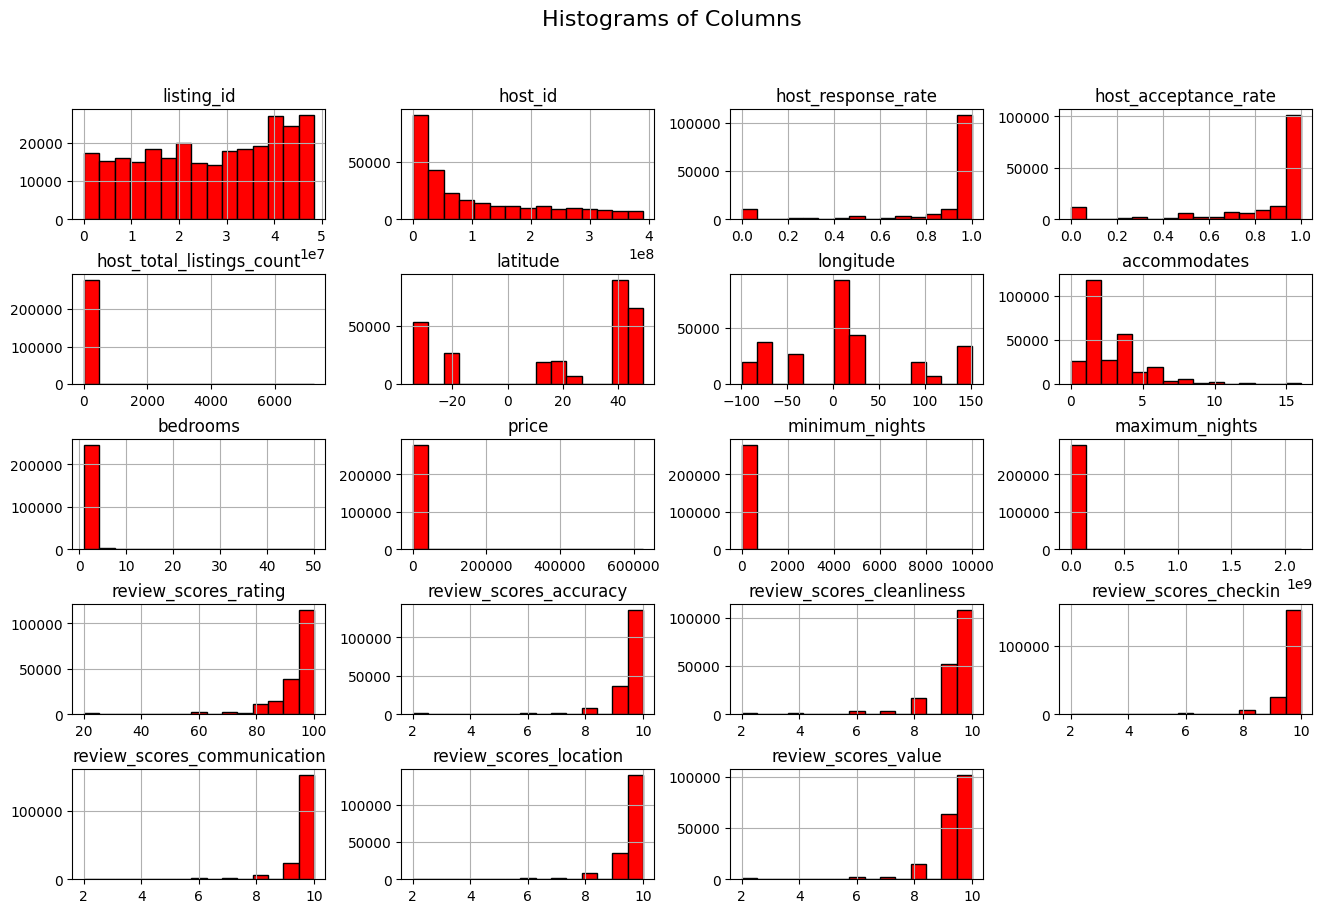

In [14]:
df.hist(bins=15, figsize=(16, 10), color='red', edgecolor='black')
plt.suptitle('Histograms of Columns', fontsize=16)
plt.subplots_adjust(hspace=0.5)  
plt.show()

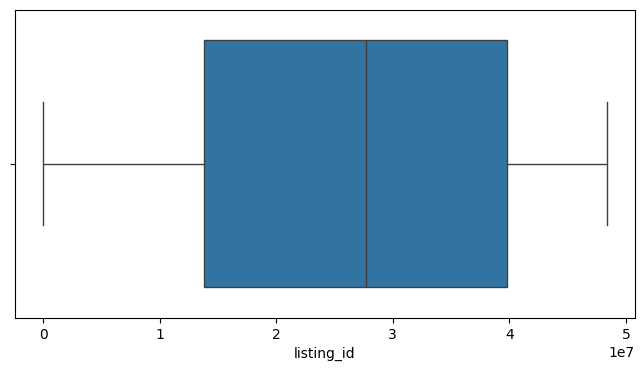

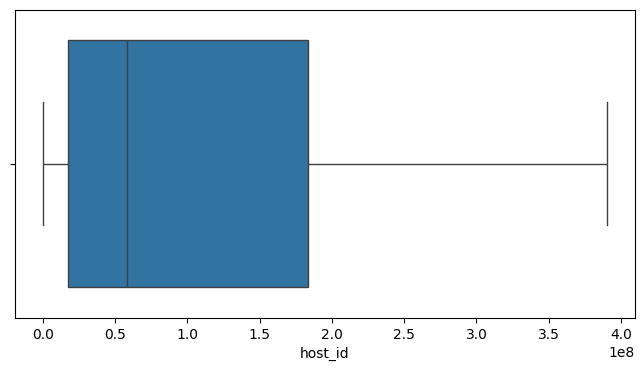

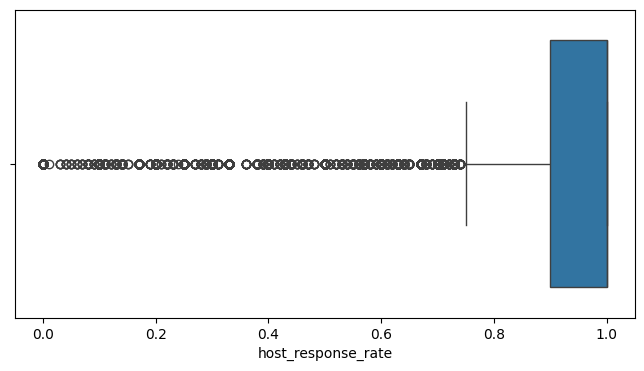

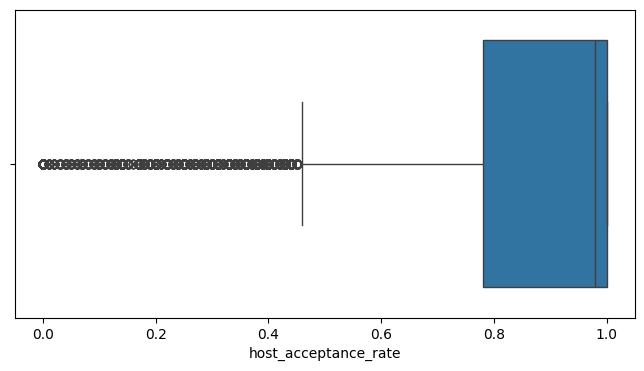

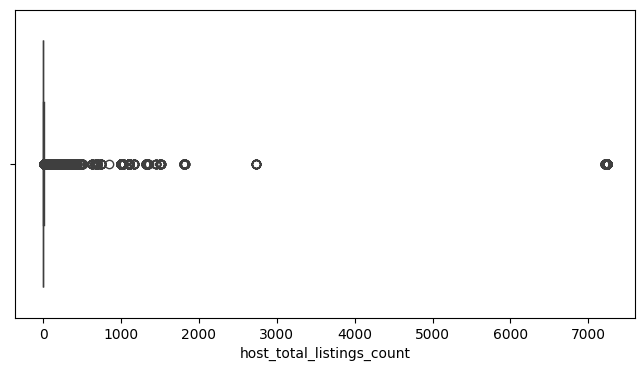

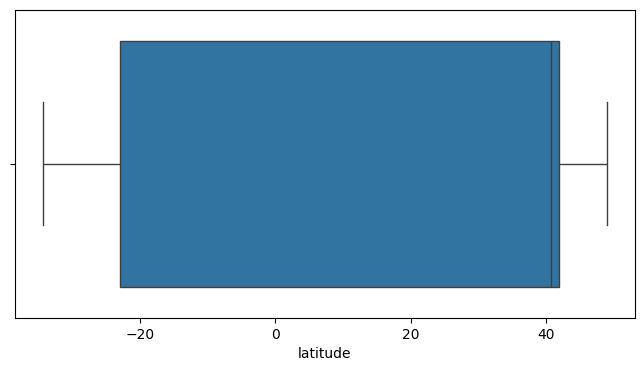

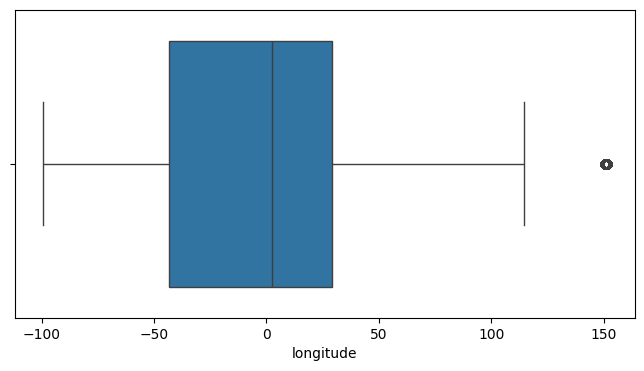

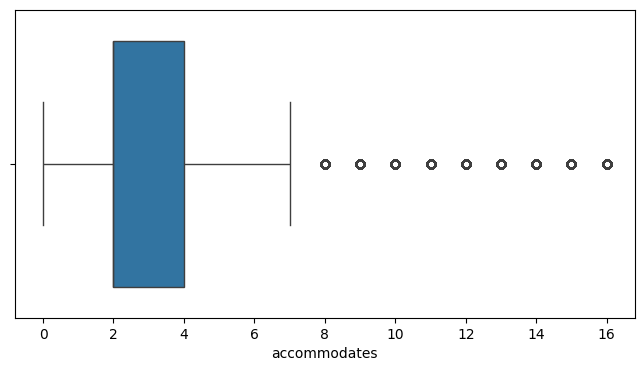

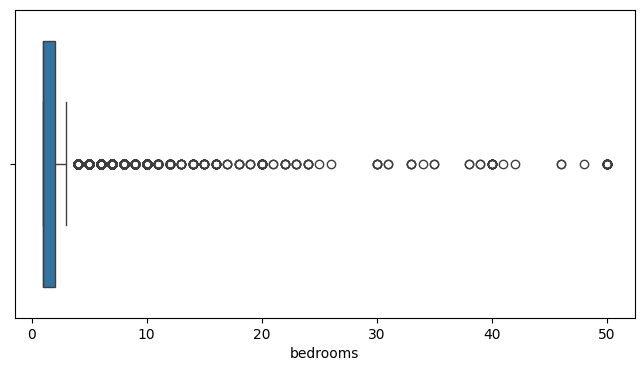

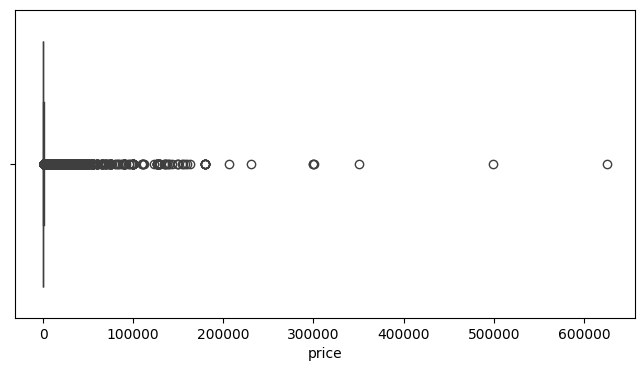

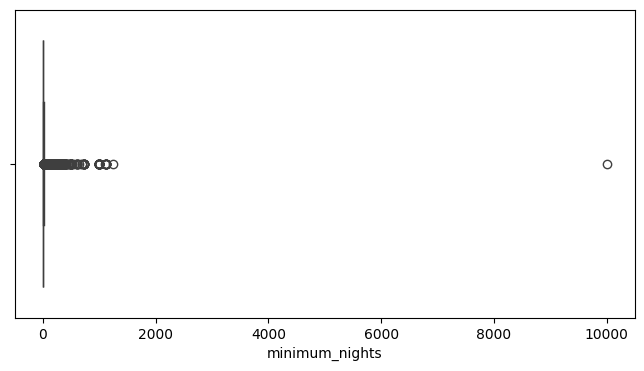

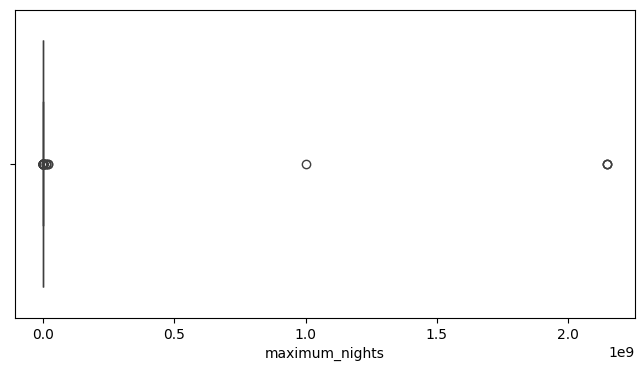

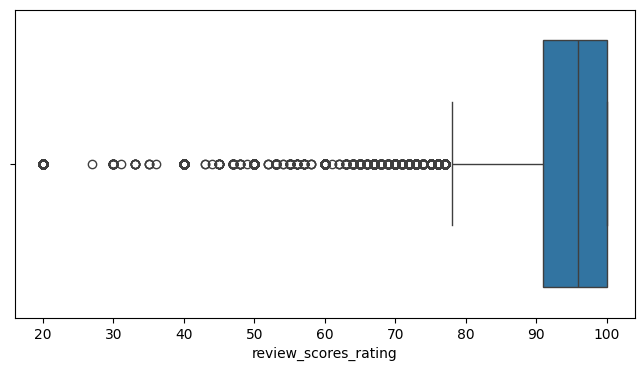

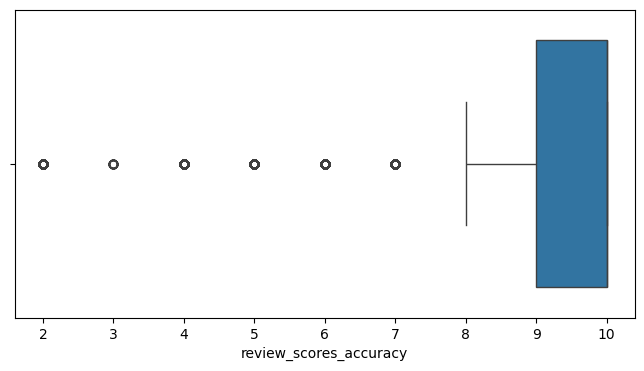

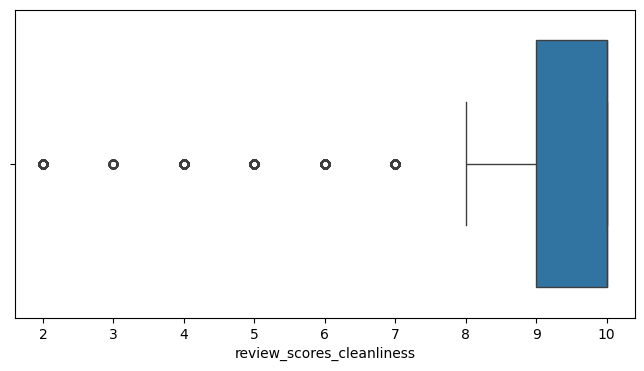

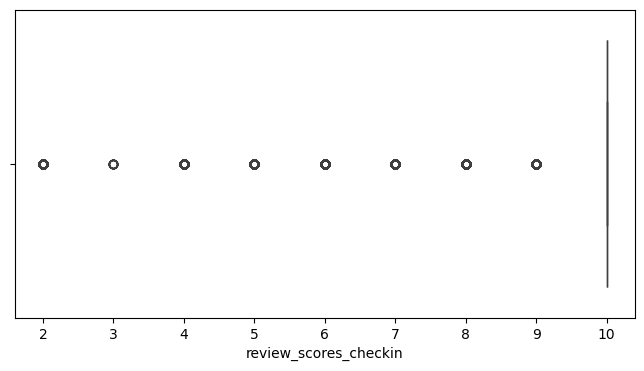

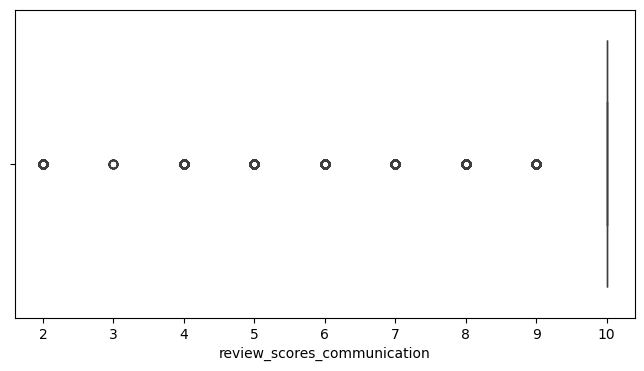

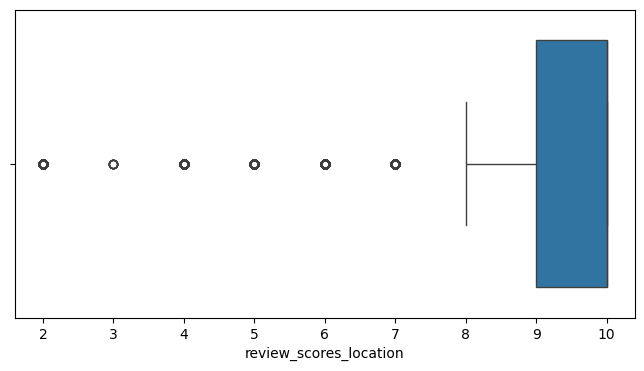

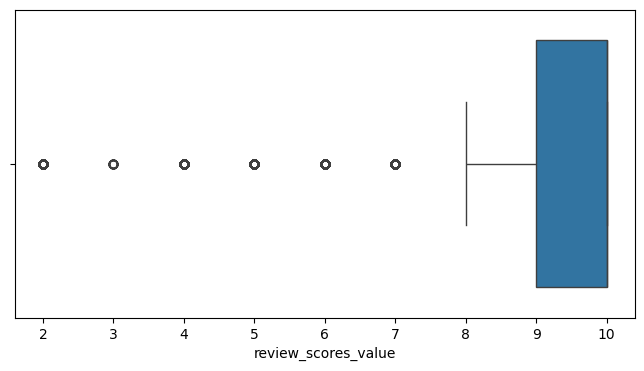

In [15]:
for col in df.select_dtypes('number'):
    boxplot(df,col)

------------------
------------------
## **Data Cleaning & Processing**
-----------------

In [16]:
df=df.drop(['listing_id', 'name', 'host_id', 'host_location','maximum_nights', 
            'host_has_profile_pic', 'host_identity_verified',
            'district', 'city'], axis = 1)

In [17]:
# Detect & Remove outliers

numerical_data = df.select_dtypes('number') 
for column in numerical_data.columns:
    Q1=numerical_data[column].quantile(0.25)
    Q3=numerical_data[column].quantile(0.75)
    IQR = Q3-Q1

    Lower_bound = Q1 - 3*IQR
    Upper_bound = Q3 + 3*IQR

    outliers = ((numerical_data[column]>Upper_bound)|(numerical_data[column]<Lower_bound)).sum()
    Total = numerical_data[column].shape[0]
    print(f'Total of outliers in {column} are   :   {outliers}--{round(100*(outliers)/Total,2)}%    and  [ lower bound : {Lower_bound} , upper bound : {Upper_bound} ]')
        
    # if outliers > 0:
    #     df=df.loc[(df[column] <= Upper_bound) & (df[column] >= Lower_bound)]

Total of outliers in host_response_rate are   :   19889--7.11%    and  [ lower bound : 0.6000000000000001 , upper bound : 1.2999999999999998 ]
Total of outliers in host_acceptance_rate are   :   11929--4.26%    and  [ lower bound : 0.1200000000000001 , upper bound : 1.66 ]
Total of outliers in host_total_listings_count are   :   30613--10.94%    and  [ lower bound : -8.0 , upper bound : 13.0 ]
Total of outliers in latitude are   :   0--0.0%    and  [ lower bound : -217.58339000000004 , upper bound : 236.52761000000004 ]
Total of outliers in longitude are   :   0--0.0%    and  [ lower bound : -259.75235 , upper bound : 245.54103999999998 ]
Total of outliers in accommodates are   :   3323--1.19%    and  [ lower bound : -4.0 , upper bound : 10.0 ]
Total of outliers in bedrooms are   :   1522--0.54%    and  [ lower bound : -2.0 , upper bound : 5.0 ]
Total of outliers in price are   :   17773--6.35%    and  [ lower bound : -1122.0 , upper bound : 1671.0 ]
Total of outliers in minimum_nights

In [18]:
df = df.loc[df['price'] <= 1000]

In [19]:
df.shape

(246917, 24)

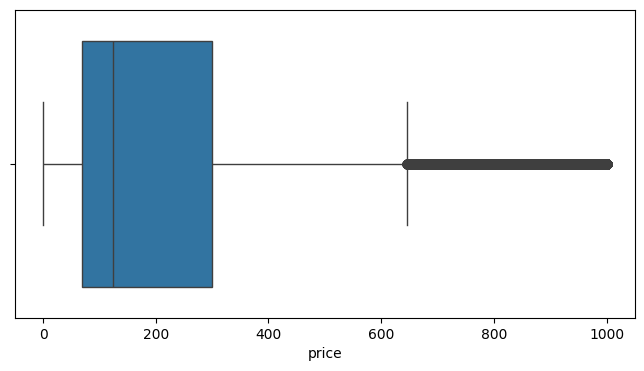

In [20]:
boxplot(df,'price')

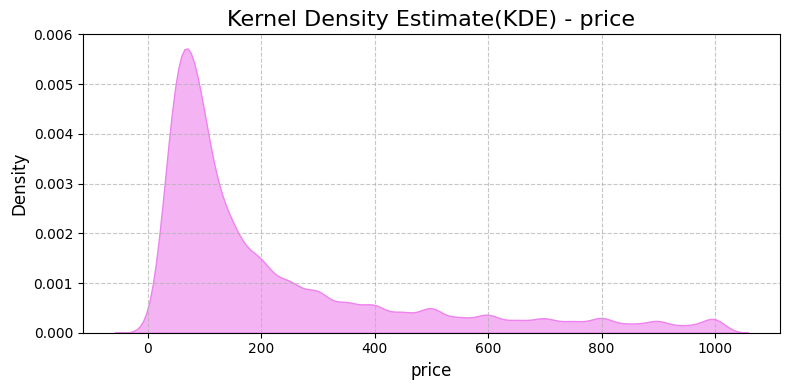

In [21]:
kde(df,'price')

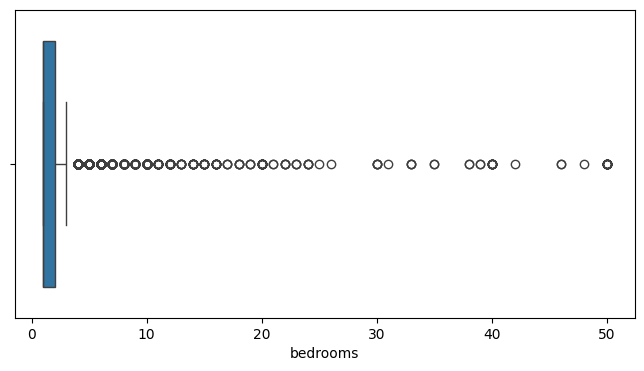

In [22]:
boxplot(df,'bedrooms')

In [23]:
df = df.loc[df['bedrooms'] <= 10]

In [24]:
df['bedrooms'].value_counts()

bedrooms
1.0     157969
2.0      42494
3.0      13323
4.0       3725
5.0        964
6.0        247
10.0        97
7.0         96
8.0         46
9.0         41
Name: count, dtype: int64

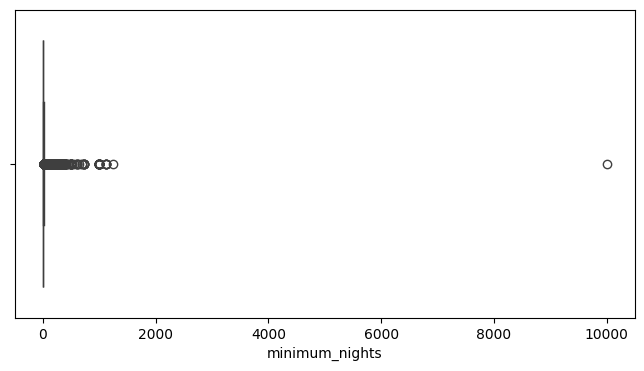

In [25]:
boxplot(df,'minimum_nights')

In [26]:
df = df.loc[df['minimum_nights'] <= 180]

In [27]:
df['minimum_nights'].value_counts()

minimum_nights
1      70634
2      48344
3      30148
30     24612
5      10735
       ...  
98         1
152        1
41         1
106        1
97         1
Name: count, Length: 118, dtype: int64

In [28]:
df.shape

(218504, 24)

In [29]:
key_amenities = [
    'Heating',
    'Kitchen',
    'Wifi',
    'Essentials',
    'Washer',
    'Long term stays allowed',
    'Smoke alarm',
    'Hair dryer',
    'Iron',
    'Dedicated workspace',
    'Hangers',
    'Hot water',
    'TV',
    'Cable TV',
    'Refrigerator',
    'Cooking basics',
    'Dishes and silverware',
    'Coffee maker',
    'Dishwasher',
    'Microwave',
    'Carbon monoxide alarm',
    'Fire extinguisher',
    'First aid kit',
    'Shampoo',
    'Elevator',
    'Paid parking off premises',
    'Free street parking',
    'Bathtub'
]

for amenity in key_amenities:
    df[amenity] = df['amenities'].str.contains(amenity, regex=False, na=False).astype(int)
    
# for amenity in key_amenities:
#     df[amenity] = df['amenities'].apply(lambda x: 1 if amenity in str(x) else 0)

In [30]:
df.columns

Index(['host_since', 'host_response_time', 'host_response_rate',
       'host_acceptance_rate', 'host_is_superhost',
       'host_total_listings_count', 'neighbourhood', 'latitude', 'longitude',
       'property_type', 'room_type', 'accommodates', 'bedrooms', 'amenities',
       'price', 'minimum_nights', 'review_scores_rating',
       'review_scores_accuracy', 'review_scores_cleanliness',
       'review_scores_checkin', 'review_scores_communication',
       'review_scores_location', 'review_scores_value', 'instant_bookable',
       'Heating', 'Kitchen', 'Wifi', 'Essentials', 'Washer',
       'Long term stays allowed', 'Smoke alarm', 'Hair dryer', 'Iron',
       'Dedicated workspace', 'Hangers', 'Hot water', 'TV', 'Cable TV',
       'Refrigerator', 'Cooking basics', 'Dishes and silverware',
       'Coffee maker', 'Dishwasher', 'Microwave', 'Carbon monoxide alarm',
       'Fire extinguisher', 'First aid kit', 'Shampoo', 'Elevator',
       'Paid parking off premises', 'Free street parkin

In [31]:
df.shape

(218504, 52)

In [32]:
df['property_type'].value_counts()

property_type
Entire apartment                105968
Private room in apartment        43666
Private room in house            11958
Entire house                      7954
Entire condominium                7270
                                 ...  
Holiday park                         1
Private room in holiday park         1
Shared room in island                1
Pension                              1
Tipi                                 1
Name: count, Length: 140, dtype: int64

In [33]:
df.isnull().sum()

host_since                        120
host_response_time             102398
host_response_rate             102398
host_acceptance_rate            88497
host_is_superhost                 120
host_total_listings_count         120
neighbourhood                       0
latitude                            0
longitude                           0
property_type                       0
room_type                           0
accommodates                        0
bedrooms                            0
amenities                           0
price                               0
minimum_nights                      0
review_scores_rating            68158
review_scores_accuracy          68388
review_scores_cleanliness       68351
review_scores_checkin           68428
review_scores_communication     68363
review_scores_location          68430
review_scores_value             68437
instant_bookable                    0
Heating                             0
Kitchen                             0
Wifi        

In [34]:
df= df.drop(['amenities','neighbourhood','host_since','host_total_listings_count'], axis=1)

In [35]:
property_categories = {
    "ENTIRE_SPACE": [
        'Entire apartment', 'Entire loft', 'Entire house', 'Entire condominium',
        'Entire townhouse', 'Entire serviced apartment', 'Entire bungalow',
        'Entire villa', 'Entire guest suite', 'Entire cottage',
        'Entire guesthouse', 'Entire chalet', 'Entire bed and breakfast',
        'Entire cabin', 'Entire tent', 'Entire hostel',
        'Entire home/apt', 'Entire resort', 'Entire dorm',
        'Entire vacation home', 'Entire floor', 'Entire in-law'
    ],
    "PRIVATE_ROOM": [
        'Private room in apartment', 'Private room in townhouse',
        'Private room in house', 'Private room in condominium',
        'Private room in guesthouse', 'Private room in serviced apartment',
        'Private room in villa', 'Private room in guest suite',
        'Private room in hostel', 'Private room in loft',
        'Private room in cabin', 'Private room in chalet',
        'Private room in cottage', 'Private room in yurt',
        'Private room in hut', 'Private room in resort',
        'Private room in bungalow', 'Private room in houseboat',
        'Private room in farm stay', 'Private room in pousada',
        'Private room in dorm', 'Private room in pension',
        'Private room in tipi', 'Private room in boat',
        'Private room in treehouse', 'Private room in cave',
        'Private room in lighthouse', 'Private room in barn',
        'Private room in bus', 'Private room in minsu',
        'Private room', 'Private room in island', 'Private room in dome house',
        'Private room in earth house', 'Private room in kezhan',
        'Private room in in-law'
    ],
"SHARED_ROOM": [
        'Shared room in apartment', 'Shared room in condominium',
        'Shared room in house', 'Shared room in townhouse',
        'Shared room in guesthouse', 'Shared room in chalet',
        'Shared room in boutique hotel', 'Shared room in bed and breakfast',
        'Shared room in hostel', 'Shared room in dorm',
        'Shared room in yurt', 'Shared room in boat',
        'Shared room in tiny house', 'Shared room in train',
        'Shared room', 'Shared room in island', 'Shared room in tent',
        'Shared room in cave', 'Shared room in tipi', 'Shared room in hut',
        'Shared room in cabin', 'Shared room in farm stay',
        'Shared room in resort', 'Shared room in bungalow',
        'Shared room in serviced apartment'
    ],

    "SPECIAL_UNIQUE": [
        'Treehouse', 'Yurt', 'Camper/RV', 'Boat', 'Houseboat',
        'Farm stay', 'Barn', 'Campsite', 'Tiny house', 'Castle',
        'Island', 'Dome house', 'Lighthouse', 'Earth house',
        'Bus', 'Igloo', 'Train', 'Tent', 'Windmill',
        'Cave', 'Pension', 'Holiday park'
    ],

    "HOTEL_STYLE": [
        'Room in aparthotel', 'Room in serviced apartment', 'Room in hotel',
        'Room in boutique hotel', 'Room in bed and breakfast',
        'Room in resort', 'Room in hostel', 'Room in nature lodge',
        'Room in guesthouse', 'Room in pension', 'Room in casa particular',
        'Room in heritage hotel', 'Holiday park'
    ],
    "CAMPING_OUTDOOR": [
        'Campsite', 'Tent', 'Tipi', 'Yurt', 'Treehouse', 'Igloo'
    ]
}


def categorize_property(ptype):
    for category, items in property_categories.items():
        if ptype in items:
            return category
    return "OTHER"


df['property_category'] = df['property_type'].apply(categorize_property)

In [36]:
df=df.drop('property_type',axis=1)

In [37]:
# Check if properties lacking reviews have a total of zero reviews
print(df[df['review_scores_rating'].isnull()]['review_scores_accuracy'].value_counts())

review_scores_accuracy
10.0    14
8.0      6
2.0      1
6.0      1
9.0      1
Name: count, dtype: int64


##### A thorough examination of the missing data pattern in the review columns revealed an exceptional operational phenomenon: units lacking a review score rating were not abandoned or brand new properties, but rather had recorded reviews ranging from 1 to 4. This behavior is structurally attributable to the platform's policy of withholding the numerical review score until a minimum threshold of detailed guest reviews is met. Based on this finding, we recommend programmatically not compensating for these values with the mean, but rather classifying them under a separate category called 'Emerging Listings' to avoid misleading pricing models.

In [38]:
review_columns = [
    'review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness',
    'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 
    'review_scores_value'
]

df['is_emerging'] = df[review_columns].isnull().any(axis=1).astype(int)

In [39]:
df['is_emerging'].isnull().sum()

np.int64(0)

In [40]:
df[review_columns].isnull().sum()

review_scores_rating           68158
review_scores_accuracy         68388
review_scores_cleanliness      68351
review_scores_checkin          68428
review_scores_communication    68363
review_scores_location         68430
review_scores_value            68437
dtype: int64

In [41]:
df.drop(review_columns,axis=1,inplace=True)

In [42]:
df['host_acceptance_rate'].mean()

np.float64(0.8261132092887306)

In [43]:
df['host_acceptance_rate'].fillna(df['host_acceptance_rate'].mean(), inplace=True) 

/tmp/ipykernel_58/2980859695.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['host_acceptance_rate'].fillna(df['host_acceptance_rate'].mean(), inplace=True)


In [44]:
df['host_response_rate'].mean()

np.float64(0.8655418324634386)

In [45]:
df['host_response_rate'].fillna(df['host_response_rate'].mean(), inplace=True) 

/tmp/ipykernel_58/3914068893.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['host_response_rate'].fillna(df['host_response_rate'].mean(), inplace=True)


In [46]:
df['host_response_time'].mode()

0    within an hour
Name: host_response_time, dtype: object

In [47]:
df['host_response_time'] = df['host_response_time'].replace({np.nan :'within an hour'}) 

In [48]:
df['bedrooms'].mode()

0    1.0
Name: bedrooms, dtype: float64

In [49]:
df['bedrooms'] = df['bedrooms'].replace({np.nan :1}) 

In [50]:
df['host_is_superhost'].mode()

0    f
Name: host_is_superhost, dtype: object

In [51]:
df['host_is_superhost'] = df['host_is_superhost'].replace({np.nan :'f'}) 

In [52]:
df['accommodates'].mode()

0    2
Name: accommodates, dtype: int64

In [53]:
df['host_is_superhost'] = df['host_is_superhost'].replace({np.nan :2}) 

In [54]:
df.isnull().sum()

host_response_time           0
host_response_rate           0
host_acceptance_rate         0
host_is_superhost            0
latitude                     0
longitude                    0
room_type                    0
accommodates                 0
bedrooms                     0
price                        0
minimum_nights               0
instant_bookable             0
Heating                      0
Kitchen                      0
Wifi                         0
Essentials                   0
Washer                       0
Long term stays allowed      0
Smoke alarm                  0
Hair dryer                   0
Iron                         0
Dedicated workspace          0
Hangers                      0
Hot water                    0
TV                           0
Cable TV                     0
Refrigerator                 0
Cooking basics               0
Dishes and silverware        0
Coffee maker                 0
Dishwasher                   0
Microwave                    0
Carbon m

In [55]:
df.duplicated().sum()

np.int64(426)

In [56]:
df.drop_duplicates(inplace = True)

In [57]:
def sup(a):
    if a == 'f':
        return 'No'
    else :
        return 'Yes'

df['host_is_superhost'] = df['host_is_superhost'].apply(lambda x: sup(x))

In [58]:
def bok(a):
    if a == 'f':
        return 'No'
    else :
        return 'Yes'

df['instant_bookable'] = df['instant_bookable'].apply(lambda x: bok(x))

In [59]:
amnCols = ['Heating', 'Kitchen', 'Wifi',
       'Essentials', 'Washer', 'Long term stays allowed', 'Smoke alarm',
       'Hair dryer', 'Iron', 'Dedicated workspace', 'Hangers', 'Hot water',
       'TV', 'Cable TV', 'Refrigerator', 'Cooking basics',
       'Dishes and silverware', 'Coffee maker', 'Dishwasher', 'Microwave',
       'Carbon monoxide alarm', 'Fire extinguisher', 'First aid kit',
       'Shampoo', 'Elevator', 'Paid parking off premises',
       'Free street parking', 'Bathtub']

amenities_df = df[amnCols]

reconstructed_amenities = amenities_df.apply(lambda col: np.where(col == 1, col.name, ''), axis=0)

df['amenities'] = reconstructed_amenities.apply( lambda row: [amenity for amenity in row if amenity != ''], axis=1)

df['amenities'] = df['amenities'].apply(lambda x: "[" + ", ".join(x) + "]")

In [60]:
df['count of amenities'] = df['amenities'].apply(lambda x: len(x.split(',')))
df['count of amenities']

0          5
1          7
2          6
3          5
4         11
          ..
279707    12
279708    12
279709    13
279710    15
279711    14
Name: count of amenities, Length: 218078, dtype: int64

In [61]:
df['beds_per_room'] = df['accommodates'] / (df['bedrooms'])
df['beds_per_room'] = df['beds_per_room'].apply(lambda x:round(x))

In [62]:
df['beds_per_room'].sample(5)

178745    2
94809     2
183809    4
118372    1
209581    2
Name: beds_per_room, dtype: int64

In [63]:
# df.to_csv('data_for_anaysis.csv',index=False)

---------------------------------------
## **Analysis & Statistical Tests**
---------------------------------------

In [64]:
# # Variance Inflation Factor (VIF) for detecting Multicollinearity

# from statsmodels.stats.outliers_influence import variance_inflation_factor

# X = df[['bedrooms', 'accommodates', 'minimum_nights', 'count of amenities']].dropna()

# vif_data = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
# print(vif_data)

- #### **Correlation**

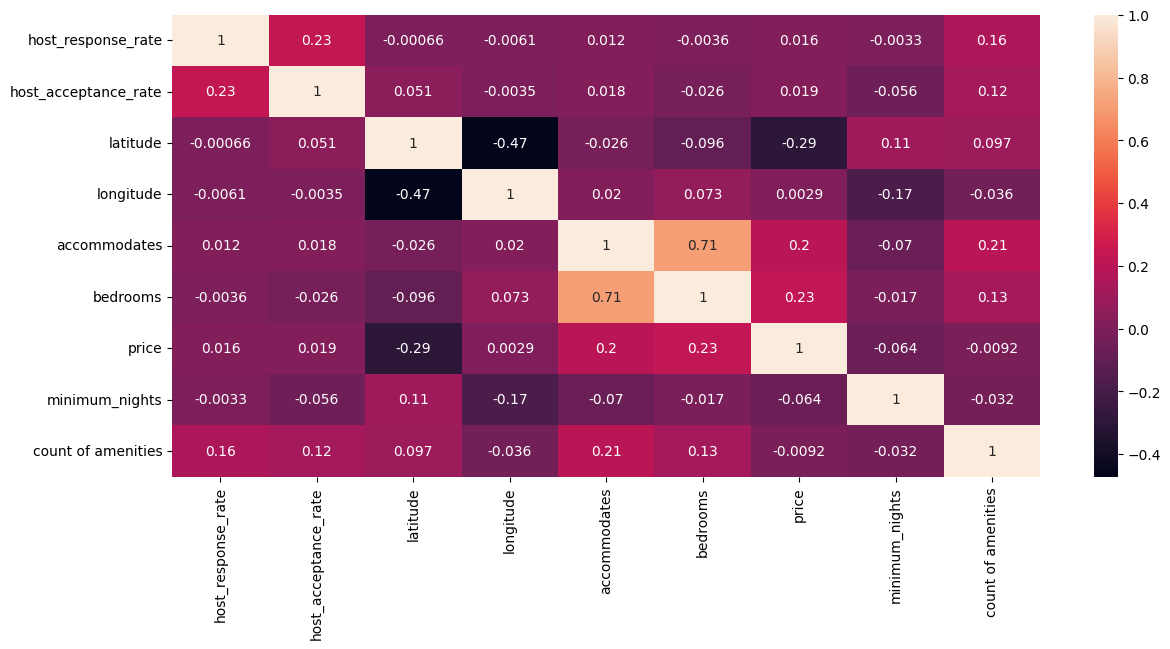

In [65]:
cols = ['host_response_rate', 'host_acceptance_rate','latitude', 'longitude',
       'accommodates', 'bedrooms', 'price', 'minimum_nights','count of amenities']


plt.figure(figsize=(14,	6))
sns.heatmap(df[cols].corr(), annot=True)
plt.show()

#### **Core Price Drivers**
##### Property Size and Capacity: A strong positive correlation (0.71) was found between the number of bedrooms and the accommodation capacity. These two variables are the primary statistical drivers of the price per night, with a correlation ranging from 0.23 to 0.2.

##### Geographic Factor (The Latitude): The analysis revealed a visible inverse correlation (−0.29) between price and latitude. This suggests, both demographically and commercially, that upscale neighborhoods, or the vibrant city center, are heavily concentrated in the southern part of the city under study.

##### Property Size and Service Quality: Larger properties are committed to providing additional and diverse services and amenities that cater to groups, as evidenced by a positive correlation (0.19) between capacity and the number of services.

#### **Host Engagement**
##### Response Speed Increases Effectiveness: The matrix revealed a positive correlation of 0.23 between the host response rate and the host acceptance rate, reflecting that hosts who are more proactive in communication are more committed to operating their properties.

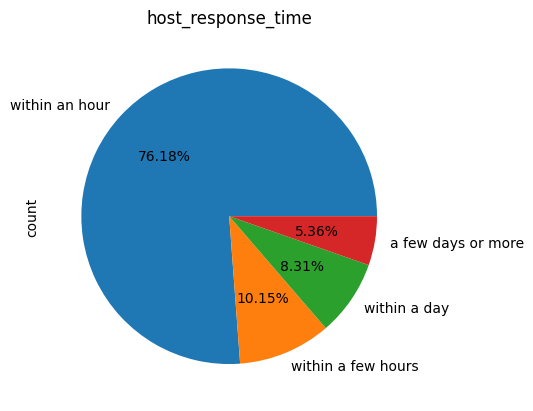

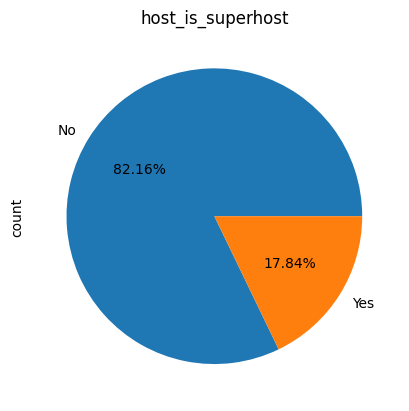

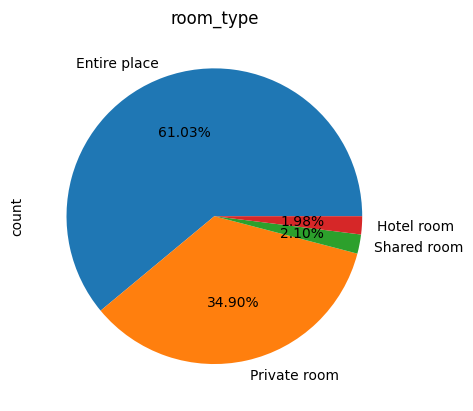

In [66]:
cols = ['host_response_time','host_is_superhost','room_type']
for col in df[cols]:
    pie(df,col)

- #### **Price Distribution**

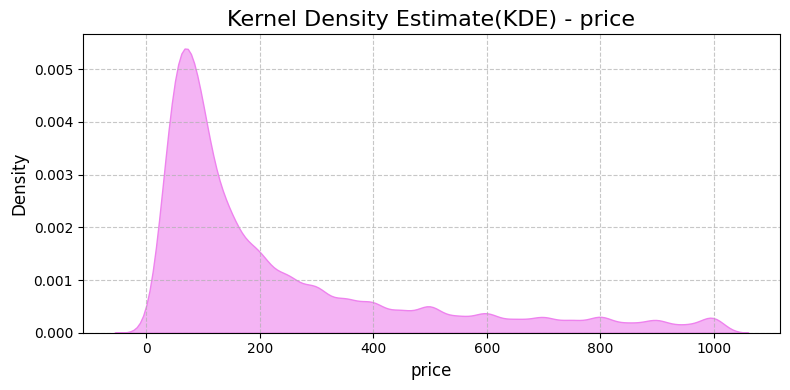

In [67]:
kde(df,'price')

----------------------------
- #### **Host response time vs Price**

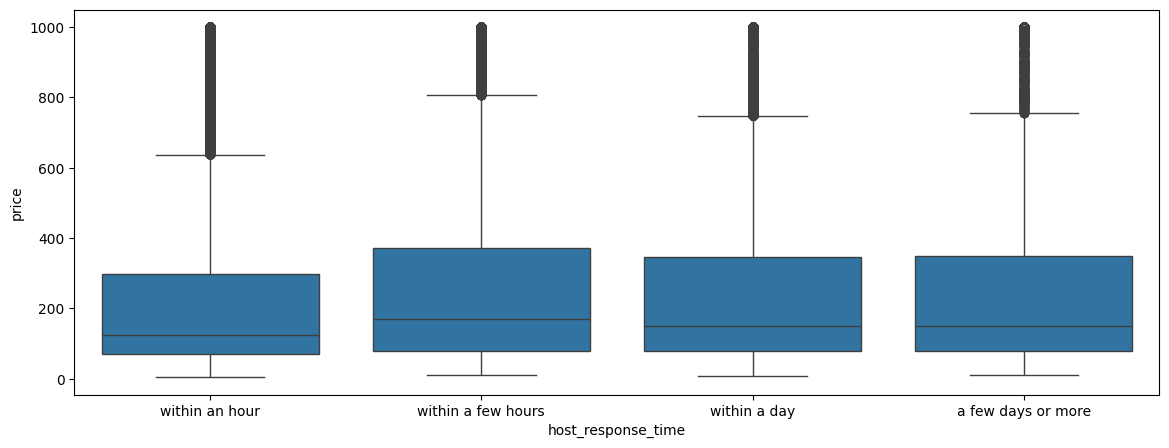

In [68]:
boxplot2(df,'host_response_time','price')

##### Analysis of host response time categories reveals an interesting pattern: properties whose hosts take several hours to respond consistently command higher rates compared to those with immediate responses. This is statistically attributed to the fact that luxury and exclusive properties are managed personally and meticulously by their owners, requiring more time to process requests, while budget properties rely on automated response systems to expedite daily bookings.

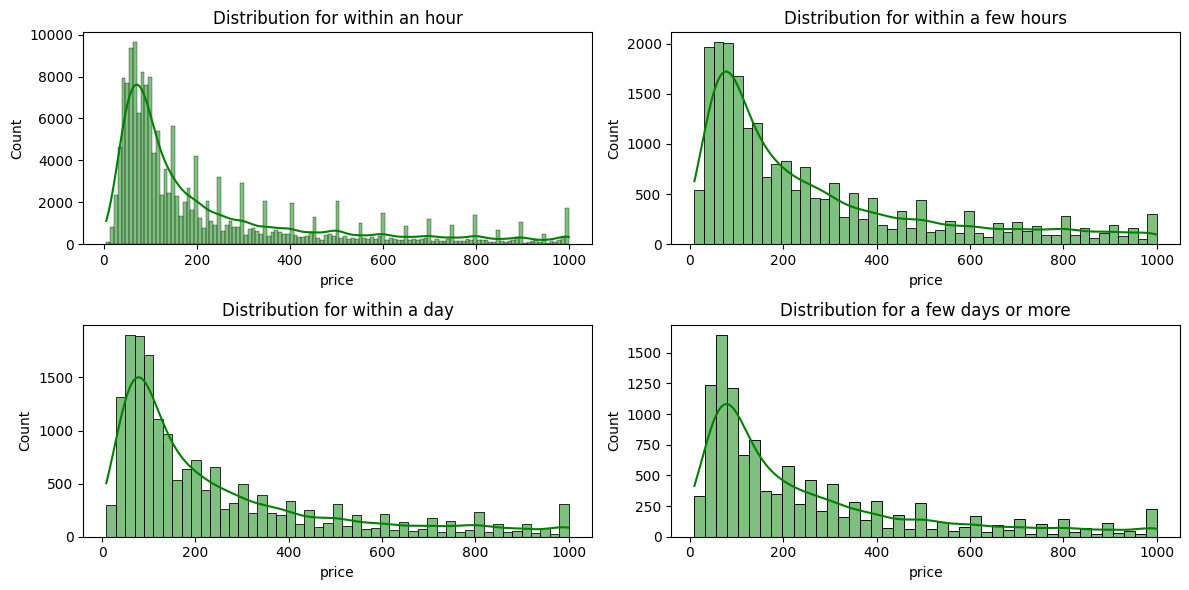

In [69]:
group_distribution(df,'host_response_time','price')

In [70]:
within_an_hour = df[df['host_response_time']=='within an hour']['price'].dropna()
within_a_few_hours = df[df['host_response_time']=='within a few hours']['price'].dropna()
within_a_day = df[df['host_response_time']=='within_a_day']['price'].dropna()
a_few_days_or_more = df[df['host_response_time']=='a few days or more']['price'].dropna()

if len(within_an_hour) > 5 and len(within_a_few_hours) > 5 and len(within_a_day) > 5 and len(a_few_days_or_more) > 5:
    stat, p_value_k = st.kruskal(within_an_hour, within_a_few_hours, within_a_day, a_few_days_or_more)
    
    print(f"Kruskal-Wallis Statistic: {stat}")
    print(f"P-value: {p_value_k}")
          
    if p_value_k < 0.05:
        print("There is a significant difference")
    else :
        print("There is not a significant difference")

else:
    print("One or more sample arguments is too small")

One or more sample arguments is too small


---------------------------------------------
- #### **Room type vs Price**

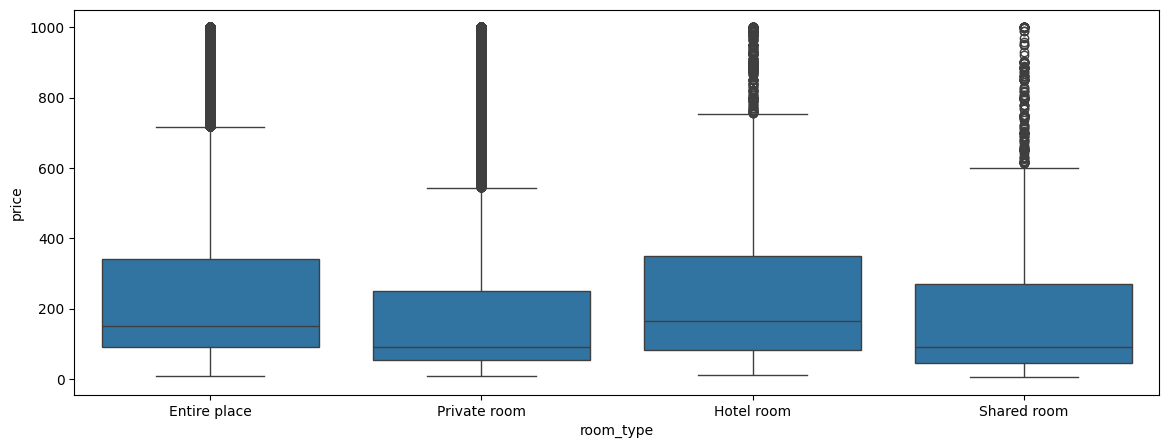

In [71]:
boxplot2(df,'room_type','price')

##### An analysis of room types reveals that prices are driven by two types of added value: hotel services and independence. Hotel rooms and entire rooms command the highest pricesthe former are associated with high-end hospitality and shared services, while the latter are linked to higher operating costs and the provision of complete amenities for groups and families. In contrast, private rooms stand out as a highly economical option (representing approximately one-third of the market), as their occupants typically stay alone or for business purposes, thus reducing the service costs required from the host.

In [72]:
entire_room = df[df['room_type']=='Entire place']['price'].dropna()
private_room = df[df['room_type']=='Private room']['price'].dropna()
hotel_room = df[df['room_type']=='Hotel room']['price'].dropna()
Shared_room = df[df['room_type']=='Shared room']['price'].dropna()

if len(entire_room) > 5 and len(private_room) > 5 and len(hotel_room) > 5 and len(Shared_room) > 5:
    stat, p_value_k = st.kruskal(entire_room, private_room, hotel_room, Shared_room)
    
    print(f"Kruskal-Wallis Statistic: {stat}")
    print(f"P-value: {p_value_k}")
          
    if p_value_k < 0.05:
        print("There is a significant difference")
    else :
        print("There is not a significant difference")

else:
    print("One or more sample arguments is too small")

Kruskal-Wallis Statistic: 10169.69758587729
P-value: 0.0
There is a significant difference


##### The analysis was not limited to visually observing price differences between room types, the behavioral hypotheses were also subjected to the advanced Kruskal-Wallis test for independent groups. The test recorded a very high variance value (10153.68) with a significance level of 0.0, providing strong statistical evidence that accommodation type is a key structural determinant in Airbnb pricing. This validates the behavioral analysis regarding the variation in operating costs and the desired levels of luxury and independence across different market segments.

------------------------------
- #### **Instant bookable vs Price**

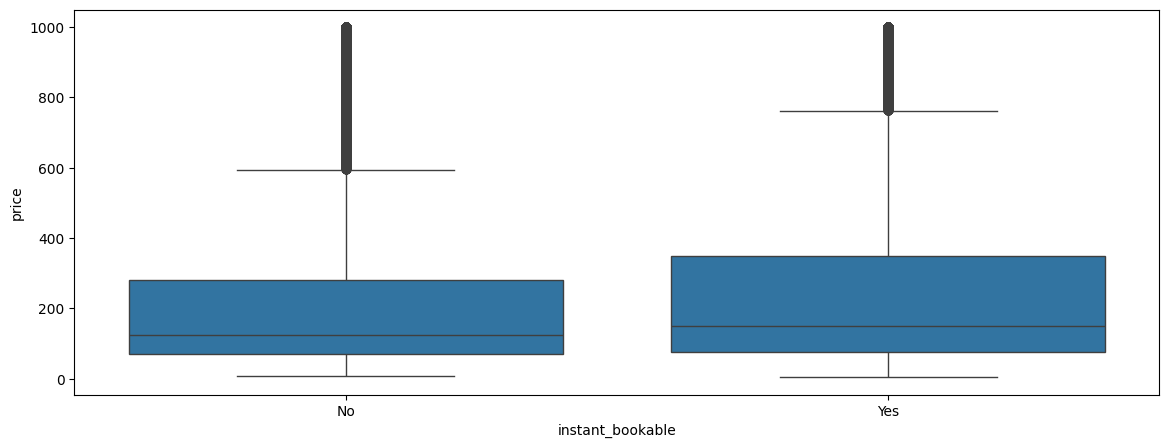

In [73]:
boxplot2(df,'instant_bookable','price')

##### Analysis of the instant bookable feature reveals a clear price disparity; properties with instant confirmation command higher prices. This statistically significant increase is attributed to the higher operating costs of professional hosts who rely on smart software and automated property management systems to ensure 24/7 availability. In contrast, individual hosts prefer traditional booking methods to minimize technical costs and allow for manual background checks, making their properties more attractive to budget-conscious travelers who are willing to wait.

In [74]:
No = df[df['instant_bookable'] == 'No']['price']
Yes = df[df['instant_bookable'] == 'Yes']['price']

stat, p_value = st.mannwhitneyu(No, Yes)

print(f"p-value: {p_value:.6f}")
if p_value < 0.05:
    print("There is a significant difference ---> H0 is rejected")
else :
    print("There is not a significant difference ---> H0 is not rejacted")

p-value: 0.000000
There is a significant difference ---> H0 is rejected


##### To confirm the behavioral hypothesis regarding the instant bookable feature, the Mann-Whitney U test was performed on independent groups. The result strongly rejected the null hypothesis (p-value = 0.00), providing conclusive mathematical evidence that the availability of instant booking confirmation is associated with a significantly higher and different pricing structure. This demonstrates that professional management strategies and digital automation are reflected as structural variables in the Airbnb market.

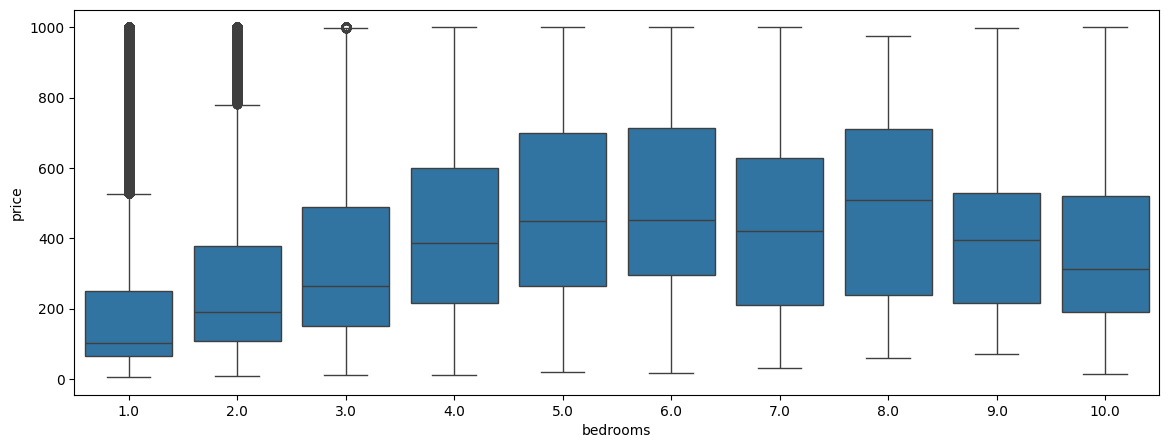

In [75]:
boxplot2(df,'bedrooms','price')

##### Analysis of the bedroom variable reveals a surprising non-linear pattern; the average price rises proportionally with the number of rooms, peaking between 6 and 8 rooms. However, the curve shows a clear decline for properties with 9 and 10 rooms. This behavior is commercially explained by the shift in the nature of properties in this range from exclusive and luxurious tourist villas to shared hostels and guesthouses, where increased bed density comes at the expense of privacy and comfort, leading to a decrease in the property's market rental value.

In [76]:
pearson_coef, p_value = st.pearsonr(df['bedrooms'], df['price'])

print(f"Pearson Coef: {pearson_coef:.3f}, P-value: {p_value}")

if p_value < 0.05:
    print("There is a significant difference ---> H0 is rejected")
else :
    print("There is not a significant difference ---> H0 is not rejacted")

Pearson Coef: 0.226, P-value: 0.0
There is a significant difference ---> H0 is rejected


##### To confirm the structural relationship between property size and market value, a Pearson statistical correlation test was conducted between the variables of number of rooms and price. The test recorded a true positive correlation coefficient of 0.226, accompanied by a statistically significant finding (p-value = 0.0), thus rejecting the null hypothesis and confirming that increasing the number of rooms in a property is a key and reliable driver of price increases on the Airbnb platform.

------------------------------
- #### **Accommodates vs Price**

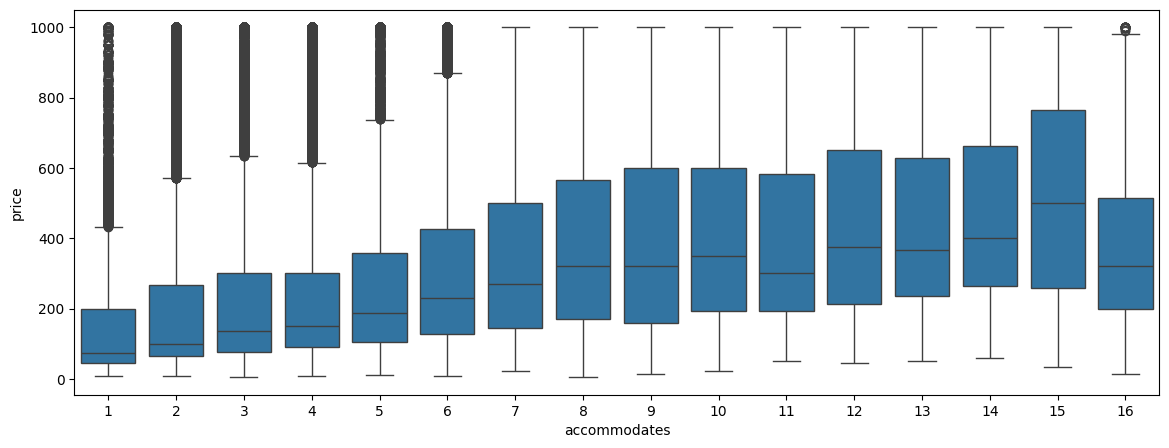

In [77]:
boxplot2(df,'accommodates','price')

In [78]:
spearman_coef, p_value_s = st.spearmanr(df['accommodates'], df['price'])
print(f"Spearman Coef: {spearman_coef:.3f}, P-value: {p_value}")

if p_value < 0.05:
    print("There is a significant difference ---> H0 is rejected")
else :
    print("There is not a significant difference ---> H0 is not rejacted")

Spearman Coef: 0.285, P-value: 0.0
There is a significant difference ---> H0 is rejected


##### Spearman's correlation test confirms a statistically significant and genuine positive relationship between a property's capacity and its price (r = 0.285, P-value = 0.0). However, visual data reveals a significant drop in median prices at critical capacities such as 11 and 16 guests. This behavior is commercially attributed to the crowding effect; these properties tend to sacrifice privacy and comfort by cramming shared beds to attract younger, budget-conscious tourist groups, resulting in lower overall rental values compared to more exclusive family properties.

------------------------------
- #### **Count of amenities vs Price**

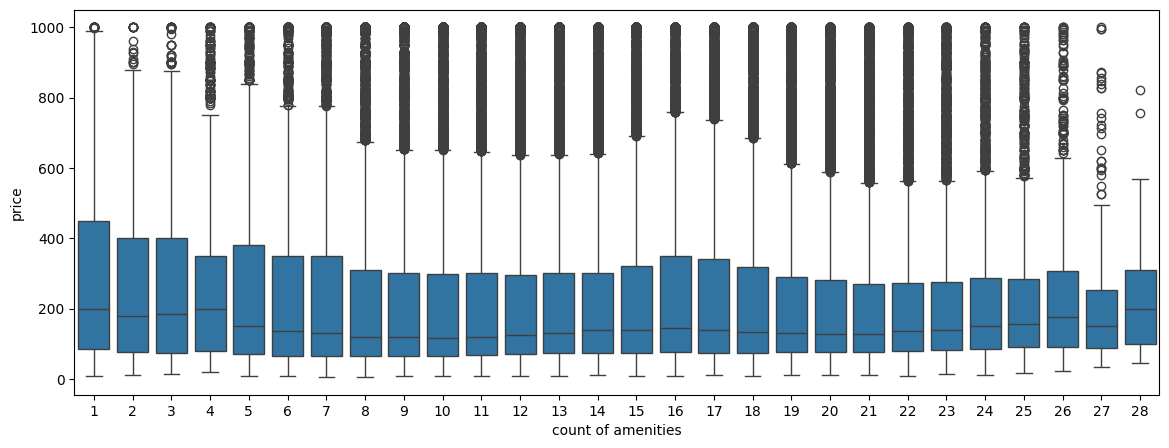

In [79]:
boxplot2(df,'count of amenities','price')

In [80]:
spearman_coef, p_value_s = st.spearmanr(df['count of amenities'], df['price'])
print(f"Spearman Coef: {spearman_coef:.3f}, P-value: {p_value}")

if p_value < 0.05:
    print("There is a significant difference ---> H0 is rejected")
else :
    print("There is not a significant difference ---> H0 is not rejacted")

Spearman Coef: 0.030, P-value: 0.0
There is a significant difference ---> H0 is rejected


##### To understand the non-linear relationship between the number of available services and the nightly price, Spearman's Rank Correlation test was applied, as it is the preferred method for skewed data. The results strongly refuted the null hypothesis, demonstrating strong statistical significance (p-value < 0.05), thus confirming a real effect of the number of services on price. However, the correlation coefficient registered a small positive value (0.030). This is commercially attributable to the fact that the price increase is driven by the exclusive luxury of the services (such as swimming pools or views) rather than simply by an increase in the quantity of basic amenities provided by most budget properties.

------------------------------
- #### **Location vs Price**

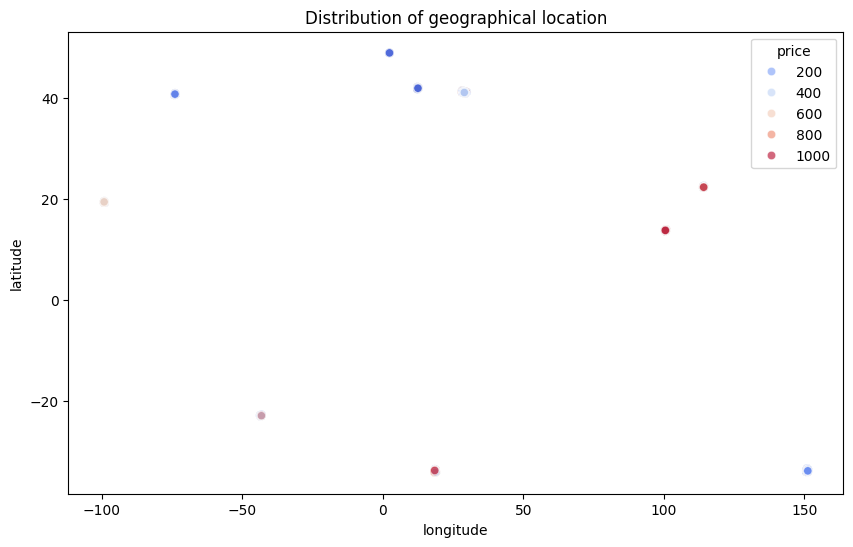

In [81]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='longitude', y='latitude', hue='price', palette='coolwarm', alpha=0.6)
plt.title('Distribution of geographical location')
plt.show()

##### The geographical distribution of properties reveals a clear spatial variation in pricing strategies. Purchasing power and luxury units (highlighted in red) are concentrated in the geographical ranges between latitudes 100 and 120, indicating that these areas represent the city's vibrant commercial or tourist center. Conversely, the inverse relationship between latitude and price is visually confirmed, with more affordable units (highlighted in blue) dominating the northern areas. The analysis also identified geographically isolated luxury units in the southern ranges, which are operationally interpreted as exclusive resorts whose high prices are based on providing seclusion and luxury away from the hustle and bustle of the city center.

--------------------------------

In [ ]:
!jupyter nbconvert --to html "airbnb-data-analysis.ipynb"